## Modelo de Deep Learning usando Tensorflow

In [1]:
#import dask.dataframe as dd
import pandas as pd
from sklearn.preprocessing import StandardScaler,OneHotEncoder
df = pd.read_csv("../../../data/ex1/eventos_espera_semana_nuevo.csv", delimiter=",")
df

,ICAO,ultimo_parado,despegue,tiempo_espera,aircraft_type,lat,lon,holding_point,fecha_despegue,hora_despegue,runway
0,3420ca,2024-12-03 15:21:22.843,2024-12-03 15:23:03.503,100.660,Medium 2 (between 34000 kg to 136000 kg),40.505962,-3.559235,Y2,2024-12-03,15,18L/36R
1,3420ca,2024-12-04 09:24:55.891,2024-12-04 09:26:36.177,100.286,Medium 2 (between 34000 kg to 136000 kg),40.504462,-3.559211,Y1,2024-12-04,9,18L/36R
2,3420ca,2024-12-04 16:16:10.860,2024-12-04 16:17:46.200,95.340,Medium 2 (between 34000 kg to 136000 kg),40.498638,-3.574646,Z4,2024-12-04,16,18R/36L
3,3420ca,2024-12-07 20:14:55.509,2024-12-07 20:16:48.101,112.592,Medium 2 (between 34000 kg to 136000 kg),40.504613,-3.559211,Y1,2024-12-07,20,18L/36R
4,3444c3,2024-12-02 14:42:10.407,2024-12-02 14:43:51.726,101.319,Medium 2 (between 34000 kg to 136000 kg),40.505824,-3.559227,Y1,2024-12-02,14,18L/36R
...,...,...,...,...,...,...,...,...,...,...,...
1291,345597,2024-12-04 11:59:33.506,2024-12-04 12:02:01.348,147.842,Medium 2 (between 34000 kg to 136000 kg),40.498341,-3.574646,Z4,2024-12-04,12,18R/36L
1292,345597,2024-12-05 14:56:14.304,2024-12-05 14:56:48.566,34.262,Medium 2 (between 34000 kg to 136000 kg),40.500057,-3.559464,Y1,2024-12-05,14,18L/36R
1293,345597,2024-12-06 16:11:57.714,2024-12-06 16:13:59.680,121.966,Medium 2 (between 34000 kg to 136000 kg),40.498829,-3.574661,Z4,2024-12-06,16,18R/36L
1294,4d22b1,2024-12-07 19:23:06.400,2024-12-07 19:25:05.533,119.133,Medium 2 (between 34000 kg to 136000 kg),40.505672,-3.559243,Y1,2024-12-07,19,18L/36R


In [2]:
df.dtypes

ICAO               object
ultimo_parado      object
despegue           object
tiempo_espera     float64
aircraft_type      object
lat               float64
lon               float64
holding_point      object
fecha_despegue     object
hora_despegue       int64
runway             object
dtype: object

In [3]:
icaos = df[["ICAO","tiempo_espera"]]
df.head()

,ICAO,ultimo_parado,despegue,tiempo_espera,aircraft_type,lat,lon,holding_point,fecha_despegue,hora_despegue,runway
0,3420ca,2024-12-03 15:21:22.843,2024-12-03 15:23:03.503,100.660,Medium 2 (between 34000 kg to 136000 kg),40.505962,-3.559235,Y2,2024-12-03,15,18L/36R
1,3420ca,2024-12-04 09:24:55.891,2024-12-04 09:26:36.177,100.286,Medium 2 (between 34000 kg to 136000 kg),40.504462,-3.559211,Y1,2024-12-04,9,18L/36R
2,3420ca,2024-12-04 16:16:10.860,2024-12-04 16:17:46.200,95.340,Medium 2 (between 34000 kg to 136000 kg),40.498638,-3.574646,Z4,2024-12-04,16,18R/36L
3,3420ca,2024-12-07 20:14:55.509,2024-12-07 20:16:48.101,112.592,Medium 2 (between 34000 kg to 136000 kg),40.504613,-3.559211,Y1,2024-12-07,20,18L/36R
4,3444c3,2024-12-02 14:42:10.407,2024-12-02 14:43:51.726,101.319,Medium 2 (between 34000 kg to 136000 kg),40.505824,-3.559227,Y1,2024-12-02,14,18L/36R


In [4]:
## Cargar bien los tiempos
timestap_columns = ["ultimo_parado","despegue"]
for col in timestap_columns:
    df[col] = pd.to_datetime(df[col],format="%Y-%m-%d %H:%M:%S.%f")
df["fecha_despegue"] = pd.to_datetime(df["fecha_despegue"],format="%Y-%m-%d")
df.dtypes

ICAO                      object
ultimo_parado     datetime64[ns]
despegue          datetime64[ns]
tiempo_espera            float64
aircraft_type             object
lat                      float64
lon                      float64
holding_point             object
fecha_despegue    datetime64[ns]
hora_despegue              int64
runway                    object
dtype: object

In [5]:
categorical_columns = df.select_dtypes("object")
categorical_columns.columns.drop("ICAO")

Index(['aircraft_type', 'holding_point', 'runway'], dtype='object')

In [6]:
encoder = OneHotEncoder(sparse_output=False)

categorical_columns = df.select_dtypes("object").columns.drop("ICAO")

encoded_data = encoder.fit_transform(df[categorical_columns])

df_encoded = pd.DataFrame(encoded_data, columns = encoder.get_feature_names_out())
df = df.drop(columns = categorical_columns)
df_encoded = pd.concat([df,df_encoded],axis = 1)

In [7]:
def calcular_tiempo_relativo(tiempo_referencia,tiempo_fila):
    tiempo_referencia_segundos = tiempo_referencia.timestamp()
    tiempo_fila_segundos = tiempo_fila.timestamp()
    return (tiempo_referencia_segundos - tiempo_fila_segundos)

In [8]:
df_encoded_sorted = df_encoded.sort_values("despegue",ascending = False).reset_index()
df_encoded_sorted.head(2)

,index,ICAO,ultimo_parado,despegue,tiempo_espera,lat,lon,fecha_despegue,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),...,holding_point_Z1,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L,runway_nan
0,230,34510a,2024-12-06 13:46:55.232,2024-12-07 23:22:51.394,120956.162,40.498260,-3.574646,2024-12-07,23,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,672,4cad3d,2024-12-07 23:14:53.199,2024-12-07 23:17:51.093,177.894,40.497153,-3.574630,2024-12-07,23,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
df_encoded_sorted.columns

Index(['index', 'ICAO', 'ultimo_parado', 'despegue', 'tiempo_espera', 'lat',
       'lon', 'fecha_despegue', 'hora_despegue',
       'aircraft_type_Heavy (larger than 136000 kg)',
       'aircraft_type_High vortex aircraft',
       'aircraft_type_Light (less than 7000 kg)',
       'aircraft_type_Medium 1 (between 7000 kg and 34000 kg)',
       'aircraft_type_Medium 2 (between 34000 kg to 136000 kg)',
       'aircraft_type_No category information', 'holding_point_K1',
       'holding_point_K2', 'holding_point_KA6', 'holding_point_KA8',
       'holding_point_LA', 'holding_point_LB', 'holding_point_LC',
       'holding_point_LD', 'holding_point_LE', 'holding_point_Y1',
       'holding_point_Y2', 'holding_point_Y3', 'holding_point_Z1',
       'holding_point_Z2', 'holding_point_Z3', 'holding_point_Z4',
       'holding_point_Z6', 'runway_14L/32R', 'runway_14R/32L',
       'runway_18L/36R', 'runway_18R/36L', 'runway_nan'],
      dtype='object')

Eliminamos columnas innecesarias o columnas con timestamp (no sabemos como preprocesar todavia)

In [10]:
df_encoded_sorted["hora_parado"] = df_encoded_sorted["ultimo_parado"].dt.hour
df_encoded_sorted = df_encoded_sorted.drop(columns=["index", "ICAO", "fecha_despegue", "ultimo_parado"])

In [16]:
df_encoded_sorted.head()

,despegue,tiempo_espera,lat,lon,hora_despegue,aircraft_type_Heavy (larger than 136000 kg),aircraft_type_High vortex aircraft,aircraft_type_Light (less than 7000 kg),aircraft_type_Medium 1 (between 7000 kg and 34000 kg),aircraft_type_Medium 2 (between 34000 kg to 136000 kg),...,holding_point_Z2,holding_point_Z3,holding_point_Z4,holding_point_Z6,runway_14L/32R,runway_14R/32L,runway_18L/36R,runway_18R/36L,runway_nan,hora_parado
0,2024-12-07 23:22:51.394,120956.162,40.498260,-3.574646,23,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13
1,2024-12-07 23:17:51.093,177.894,40.497153,-3.574630,23,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23
2,2024-12-07 22:10:10.102,99.570,40.497118,-3.574817,22,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,22
3,2024-12-07 22:04:48.160,154.112,40.496521,-3.574814,22,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,22
4,2024-12-07 21:11:43.880,83.835,40.507081,-3.559227,21,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,21


In [11]:
despegues = []
avion = []
y = []
for indice, fila in df_encoded_sorted.iterrows():
    if indice < len(df_encoded_sorted) - 1:  # Verificar que no sea el último índice
        tiempo_referencia = fila["despegue"]
        
        # Seleccionar solo las filas a partir del índice
        tiempos= df_encoded_sorted.iloc[indice:].apply(
            lambda row: calcular_tiempo_relativo(tiempo_referencia, row["despegue"]), axis=1)
        
        # Filtrar el DataFrame en función de la columna 'ventana'
        ##df_filter = df_encoded_sorted[(df_encoded_sorted["ventana"] <= 1800)]
    
        tiempos = tiempos[tiempos <=1800]
   
        df_concat = pd.concat([df_encoded_sorted.iloc[indice: indice + len(tiempos)],tiempos],axis =1)
        
        despegues.append(df_concat.iloc[1:].drop(columns=["despegue"]).to_numpy())
        avion.append(df_concat.drop(columns=
            [ # información que no podemos conocer sober el avión que vamos a predecir
                'despegue', 'tiempo_espera', 'lat', 'lon',
                'hora_despegue', 'runway_14L/32R', 'runway_14R/32L',
                'runway_18L/36R', 'runway_18R/36L', 'runway_nan'
            ]
        ).iloc[0].to_numpy())
        y.append(df_concat.iloc[0]['tiempo_espera'])

In [12]:
despegues[0]

array([[177.894     ,  40.49715333,  -3.5746297 ,  23.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          1.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   1.        ,   0.        ,
         23.        , 300.30100012]])

In [13]:
avion[0]

array([ 1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0., 13.,  0.])

In [14]:
y[0]

120956.162

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.dense_dim = dense_dim
        self.num_heads = num_heads
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim)
        self.dense_proj = keras.Sequential(
            [layers.Dense(dense_dim, activation="relu"),
             layers.Dense(embed_dim),]
        )
        self.layernorm_1 = layers.LayerNormalization()
        self.layernorm_2 = layers.LayerNormalization()

    def call(self, inputs, mask=None):
        if mask is not None:
            mask = mask[:, tf.newaxis, :]
        attention_output = self.attention(
            inputs, inputs, attention_mask=mask)
        proj_input = self.layernorm_1(inputs + attention_output)
        proj_output = self.dense_proj(proj_input)
        return self.layernorm_2(proj_input + proj_output)

    def get_config(self):
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_heads": self.num_heads,
            "dense_dim": self.dense_dim,
        })
        return config


### Arquitectura del modelo:
- Entrada con los despegues (para que sean del mismo tamaño se emplea padding y se ignora mediante Masking)
- Entrada con la información del avión a predecir
- Los despegues se pasan al Transformer

In [18]:
from tensorflow import keras
from tensorflow.keras import layers

embed_dim = 34
num_heads = 2
dense_dim = 32
despegados_input = keras.Input(shape=(None, despegues[0].shape[1]), name="despegues")
#cola = keras.Input(shape=(None, 1), name="en_cola")
plane_input = keras.Input(shape=(len(avion[0]),), name="plane")

despegados_out = layers.Masking(mask_value=0.0)(despegados_input)  # Ignore padding
despegados_out = TransformerEncoder(embed_dim, dense_dim, num_heads)(despegados_out)
despegados_out = layers.GlobalAveragePooling1D()(despegados_out)

#cola_out = keras.layers.SimpleRNN(8, return_sequences=False)(cola)
plane_out = keras.layers.Dense(8, activation="relu")(plane_input)

# Combine all processed inputs
combined = keras.layers.Concatenate()([despegados_out, plane_out])#, cola_out])
combined = keras.layers.Dense(16, activation="relu")(combined)
combined = keras.layers.Dense(32, activation="relu")(combined)
combined = keras.layers.Dense(16, activation="relu")(combined)
result = keras.layers.Dense(1)(combined)

model = keras.Model(inputs=[despegados_input, plane_input], outputs=[result]) # cola, plane], outputs=[result])

model.summary()

c:\Users\dacoq\PD2\1090_riddle\.venv\Lib\site-packages\keras\src\layers\layer.py:939: UserWarning: Layer 'transformer_encoder' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ despegues           │ (None, None, 34)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, None, 34)  │          0 │ despegues[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, None, 34)  │          0 │ despegues[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, None)      │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, None, 34)  │     11,864 │ masking[0][0],    │
│ (TransformerEncode… │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ plane (InputLayer)  │ (None, 25)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 34)        │          0 │ transformer_enco… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        208 │ plane[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 42)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        688 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │        544 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        528 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         17 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 13,849 (54.10 KB)

 Trainable params: 13,849 (54.10 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
despegues[0]

array([[177.894     ,  40.49715333,  -3.5746297 ,  23.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          1.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   0.        ,   1.        ,
          0.        ,   0.        ,   0.        ,   0.        ,
          0.        ,   0.        ,   1.        ,   0.        ,
         23.        , 300.30100012]])

#### Hay aviones sin despegues anteriormente, los eliminamos (aunque no es una decisión justificada, es para que el algoritmo funcione)

In [20]:
import numpy as np

filtro = [len(d) > 0 for d in despegues]
despegues_proc = [d for d in despegues if len(d) > 0]
despegues_proc = tf.ragged.constant(despegues_proc).to_tensor()
avion_proc = np.array(avion)[filtro]
y_proc = np.array(y)[filtro]

In [21]:
len(despegues_proc), len(y_proc), len(avion_proc)

(1238, 1238, 1238)

#### Separamos en train y val (80/20)

In [ ]:
n_rows = len(y_proc)
test_size = int(0.2 * n_rows)

indices_permutation = np.random.permutation(n_rows)
shuffled_despegues = tf.gather(despegues_proc, indices_permutation)
shuffled_avion = avion_proc[indices_permutation]
shuffled_y = y_proc[indices_permutation]


X_val, y_val = [shuffled_despegues[:test_size], shuffled_avion[:test_size]], shuffled_y[:test_size]
X_train, y_train = [shuffled_despegues[test_size:], shuffled_avion[test_size:]], shuffled_y[test_size:]

In [23]:
len(y_val), len(y_train)

(247, 991)

In [25]:
import wandb
import os

os.environ["WANDB_NOTEBOOK_NAME"] = "tensorflow_model.ipynb"

wandb.init(
    project='pruebaPD2',
    name="1_1_transformer",
    entity='dacoleto-complutense-university-of-madrid', 
    config={
        'learning_rate': 0.1,  # Coincide con RMSprop
        'batch_size': 64,
        'epochs': 10
    }
)


In [ ]:
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1), loss="mean_squared_error", metrics=[keras.metrics.RootMeanSquaredError()])

from wandb.integration.keras import WandbMetricsLogger
from wandb.integration.keras import WandbModelCheckpoint

wandb_metrics_logger = WandbMetricsLogger()
wandb_model_checkpoint = WandbModelCheckpoint("1_1_model_transformer.keras")


In [ ]:

history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[wandb_metrics_logger, wandb_model_checkpoint])

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 17368566.0000 - root_mean_squared_error: 3491.9805 - val_loss: 2715.4124 - val_root_mean_squared_error: 52.1096
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9378162.0000 - root_mean_squared_error: 2368.0210 - val_loss: 2253.5015 - val_root_mean_squared_error: 47.4711
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 11523929.0000 - root_mean_squared_error: 2493.0259 - val_loss: 6470.9673 - val_root_mean_squared_error: 80.4423
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 25810606.0000 - root_mean_squared_error: 4877.3931 - val_loss: 1687.9926 - val_root_mean_squared_error: 41.0852
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 38152800.0000 - root_mean_squared_error: 5768.7500 - val_loss: 8360.3555 - val_root_mean_squared_error: 91.4350
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4839713.5000 - root_mean_squared_error: 1661.3024 - val_loss: 17650.0176 - val_root_mea

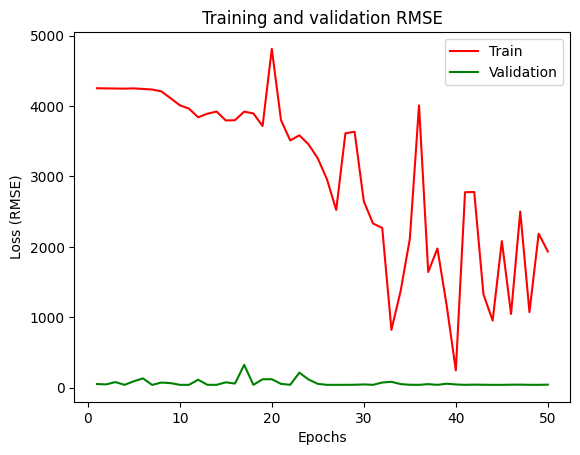

In [125]:
import matplotlib.pyplot as plt

loss = history.history['root_mean_squared_error']
val_loss = history.history['val_root_mean_squared_error']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'r', label='Train')
plt.plot(epochs, val_loss, 'g', label='Validation')

plt.title('Training and validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('Loss (RMSE)')
plt.legend()

plt.show()

Al analizar el RMSE de amos subconjuntos, parece que el error de validación no cambia significativamente, pero es bastante bajo, mientras que el error de entrenamiento flúctua de forma periódica, lo cual sugiere un error en la estructura del modelo.

Vemos algunas predicciones del conjunto de validacion

In [127]:
print("PREDICTED")
print(model.predict(X_val).flatten()[:5])
print("TRUE")
print(y_val[:5])

PREDICTED
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
[134.34732 134.34732 134.34732 134.34732 134.34732]
TRUE
[205.13   96.668 138.393 142.864  94.698]
